# Task 3: Visualise Traffic Patterns

In [38]:
import logging

log_file = r"C:\Users\symev\OneDrive\Training\Emeritus\capstone project\emeritus captone project\part2_python\visualisation.log"

logger = logging.getLogger(__name__)
logger.setLevel(logging.DEBUG)

logger.handlers.clear()

file_handler = logging.FileHandler(
    log_file,
    mode="w",
    encoding="utf-8"
)

formatter = logging.Formatter(
    "{asctime} - {levelname} - {name} - {message}",
    style="{",
    datefmt="%Y-%m-%d %H:%M:%S"
)

file_handler.setFormatter(formatter)
logger.addHandler(file_handler)

# Test that logging is working
logger.info("Logging started successfully.")

INFO:__main__:Logging started successfully.


In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [40]:
try:
    # Load the raw CSV file
    df = pd.read_csv('C:\\Users\\symev\\OneDrive\\Training\\Emeritus\\capstone project\\emeritus captone project\\Metro_Interstate_Traffic_Volume_Cleaned_FeatureEngineering.csv')

    # Get number of rows and columns
    rows, columns = df.shape

    # Log successful data loading
    logger.info(
        "Raw CSV file loaded successfully: %d rows and %d columns.",
        rows,
        columns
    )

    # Display confirmation and first few rows
    print(f"\nFile loaded successfully!")
    print(f"Rows: {rows}")
    print(f"Columns: {columns}")
    print("\nFirst 5 rows:")
    print(df.head())

except FileNotFoundError:
    logger.error(f"File not found: '{file_path}'.")

except pd.errors.EmptyDataError:
    logger.error("The CSV file is empty.")

except pd.errors.ParserError:
    logger.error("The CSV file could not be parsed. Please check its format.")

except PermissionError:
    logger.error(f"Permission denied when trying to access '{file_path}'.")

except OSError as e:
    logger.error(f"Error reading the file: {e}")

INFO:__main__:Raw CSV file loaded successfully: 48176 rows and 30 columns.



File loaded successfully!
Rows: 48176
Columns: 30

First 5 rows:
  holiday    temp  rain_1h  snow_1h  clouds_all weather_main  \
0    None  288.28      0.0      0.0          40       Clouds   
1    None  289.36      0.0      0.0          75       Clouds   
2    None  289.58      0.0      0.0          90       Clouds   
3    None  290.13      0.0      0.0          90       Clouds   
4    None  291.14      0.0      0.0          75       Clouds   

  weather_description            date_time  traffic_volume  hour  ...  \
0    Scattered Clouds  2012-10-02 09:00:00            5545     9  ...   
1       Broken Clouds  2012-10-02 10:00:00            4516    10  ...   
2     Overcast Clouds  2012-10-02 11:00:00            4767    11  ...   
3     Overcast Clouds  2012-10-02 12:00:00            5026    12  ...   
4       Broken Clouds  2012-10-02 13:00:00            4918    13  ...   

   weather_Rain  weather_Smoke  weather_Snow  weather_Squall  \
0             0              0             0  

In [41]:
# Parse date_time as datetime
df['date_time'] = pd.to_datetime(
    df['date_time'],
    errors='coerce'
)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48176 entries, 0 to 48175
Data columns (total 30 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   holiday                48176 non-null  object        
 1   temp                   48176 non-null  float64       
 2   rain_1h                48176 non-null  float64       
 3   snow_1h                48176 non-null  float64       
 4   clouds_all             48176 non-null  int64         
 5   weather_main           48176 non-null  object        
 6   weather_description    48176 non-null  object        
 7   date_time              48176 non-null  datetime64[ns]
 8   traffic_volume         48176 non-null  int64         
 9   hour                   48176 non-null  int64         
 10  day_of_week            48176 non-null  int64         
 11  is_weekend             48176 non-null  int64         
 12  hour_sin               48176 non-null  float64       
 13  h

# Traffic demand by hour 

In [42]:
# Calculate average traffic volume for each hour
average_hourly_traffic = df.groupby('hour')['traffic_volume'].mean()

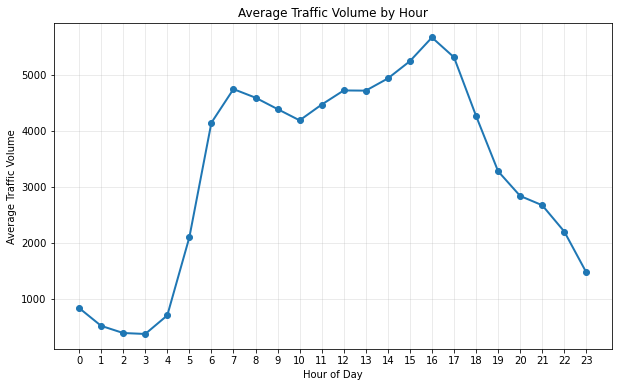

In [43]:
# Create line chart
plt.figure(figsize=(10, 6))

plt.plot(
    average_hourly_traffic.index,
    average_hourly_traffic.values,
    marker='o',
    linewidth=2
)

# Chart title and labels
plt.title('Average Traffic Volume by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Average Traffic Volume')

# Set x-axis to show every hour
plt.xticks(range(24))

plt.grid(True, alpha=0.3)

plt.show()


The line graph above shows the average traffic volume throughout a day. The chart indicates that traffic volume is generally higher between 0600 and 2200 hoursm with the peak at 1600hours presumably when workers are starting to leave their workplaces. This provides a useful basis for narrowing the scope of further analysis, particularly by focusing on this period when investigating the relationship between weather conditions and traffic congestion

In [44]:
# File path for saved figure
file_path = "average_hourly_traffic.png"

# Save the figure
plt.savefig(file_path, dpi=300, bbox_inches='tight')

# Log successful save
logger.info(
    "Figure saved successfully: %s",
    file_path
)


INFO:__main__:Figure saved successfully: average_hourly_traffic.png


<Figure size 432x288 with 0 Axes>

# Weekday vs weekend traffic histogram


In [45]:
# Separate traffic volume into weekend and non-weekend
weekend = df[df['is_weekend'] == 1]['traffic_volume']
weekday = df[df['is_weekend'] == 0]['traffic_volume']


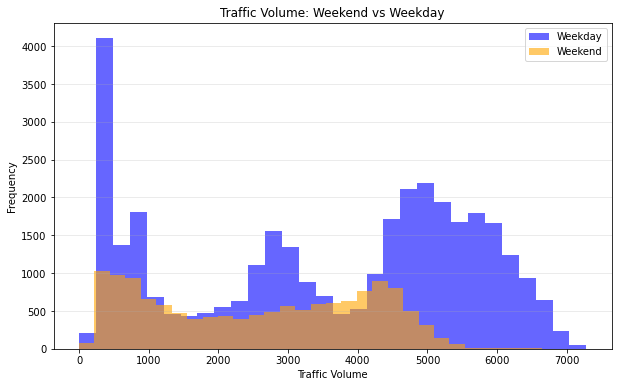

In [51]:
# Create histogram
plt.figure(figsize=(10, 6))

plt.hist(
    weekday,
    bins=30,
    alpha=0.6,
    label='Weekday',
    color='blue'
)

plt.hist(
    weekend,
    bins=30,
    alpha=0.6,
    label='Weekend',
    color='orange'
)

# Add titles and labels
plt.title('Traffic Volume: Weekend vs Weekday')
plt.xlabel('Traffic Volume')
plt.ylabel('Frequency')

# Add legend and grid
plt.legend()
plt.grid(axis='y', alpha=0.3)

# Display the graph
plt.show()

This histogram looks at the traffic volume for weekdays and weekends. This provides insight on the range of traffic volume for the two categories. This provide clear visual insight that weekdays tend to see much higher traffic counts past 5500 compared to weekend. 

This also shows that weekends tend to see a more even distribution of traffic volume whereas there are a few each spikes for weekdays. It is also interesting to note that weekdays do not follow the same distribution as weekends, seeing about three big spikes. It would be prudent to investigate the timings and conditions of the spikes to understand more. 

It should be duly noted that the balance of number of weekdays (5) vs number of weekends (2) is imbalanced and this would show up in the appearance of the histogram. 

In [47]:
# File path for saved figure
file_path = "weekday_weekend_histogram.png"

# Save the figure
plt.savefig(file_path, dpi=300, bbox_inches='tight')

# Log successful save
logger.info(
    "Figure saved successfully: %s",
    file_path
)


INFO:__main__:Figure saved successfully: weekday_weekend_histogram.png


<Figure size 432x288 with 0 Axes>

# Rainfall and traffic volume

In [48]:
#keeping only rows with rainfall in order for a more meaningful graph
is_raining= df[df['rain_1h'] > 0]
x = is_raining['rain_1h'] 
y = is_raining['traffic_volume']

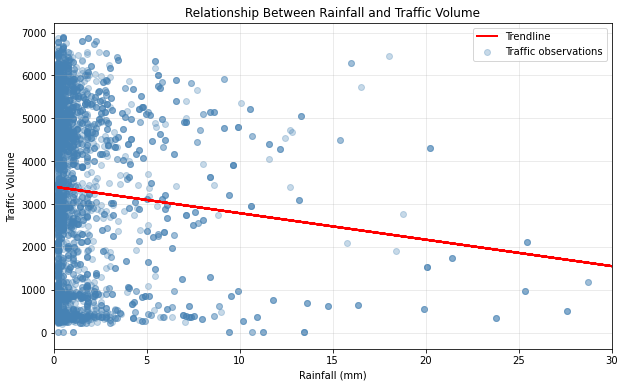

In [49]:
# Create scatterplot
plt.figure(figsize=(10, 6))

plt.scatter(
    x,
    y,
    alpha=0.3,
    color='steelblue',
    label='Traffic observations'
)

# Calculate trendline
slope, intercept = np.polyfit(x, y, 1)
trendline = slope * x + intercept

# Add trendline
plt.plot(
    x,
    trendline,
    color='red',
    linewidth=2,
    label='Trendline'
)

# Titles and labels
plt.title('Relationship Between Rainfall and Traffic Volume')
plt.xlabel('Rainfall (mm)')
plt.ylabel('Traffic Volume')

plt.xlim(0, 30) #limit to 30 as there were few outliers past that
plt.legend()
plt.grid(alpha=0.3)

plt.show()

This scatter plot shows the relationship between rainfall and traffic volume. The downwards trendline indicate that as rainfall increases, traffic volume decreases. 

It is notable that most of the rainfall concentrated <5m shows a huge range of traffic volume, suggesting that rainfall below 5mm may not have a meaningful impact or influence on traffic volume. It would be wise to look further into clustering rainfall >5mm and understanding the patterns deeper. 

In [50]:
# File path for saved figure
file_path = "rainfall_traffic.png"

# Save the figure
plt.savefig(file_path, dpi=300, bbox_inches='tight')

# Log successful save
logger.info(
    "Figure saved successfully: %s",
    file_path
)


INFO:__main__:Figure saved successfully: rainfall_traffic.png


<Figure size 432x288 with 0 Axes>